# Scene-by-Scene analysis

For each model I output a couple of scenes that might be of interest so you can look at specific metrics related to that scene.

**Setup:** set `SAVE_DIR` in the next cell to your run's output folder (e.g. `outputs/.../compare_ttc_scene_<scene_token>`).


In [21]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display, Markdown

# Edit save directory to whatever scene token you want to analyze
SAVE_DIR = Path("../work_dirs/streampetr_ttc_frozen_20e/compare_ttc_scene_fcbccedd61424f1b85dcbf8f897f9754")

SAVE_DIR = SAVE_DIR.resolve()
assert SAVE_DIR.is_dir(), f"Missing or not a directory: {SAVE_DIR}"


## Metrics summary (JSON)


In [22]:
json_path = SAVE_DIR / "scene_ttc_compare.json"
assert json_path.is_file(), json_path

with open(json_path, encoding="utf-8") as f:
    payload = json.load(f)

scene_token = payload.get("scene_token", "?")
print("scene_token:", scene_token)
print("checkpoint:", payload.get("checkpoint", "?"))
print("pretrained_baseline:", payload.get("pretrained_baseline", "?"))

summary = payload.get("summary", {})
pd.Series({
    "n_rows": summary.get("n_rows"),
    "n_finite_gt": summary.get("n_finite_gt"),
    "MAE |physics-GT| (s)": summary.get("mae_physics_s"),
    "MAE |MLP-GT| (s)": summary.get("mae_mlp_s"),
    "median AE physics (s)": summary.get("median_ae_physics_s"),
    "median AE MLP (s)": summary.get("median_ae_mlp_s"),
    "n_both_preds": summary.get("n_both_preds"),
}).to_frame("value")


scene_token: fcbccedd61424f1b85dcbf8f897f9754
checkpoint: /hpc/group/naderilab/eb408/CS372/StreamPETR/work_dirs/streampetr_ttc_frozen_20e/iter_140650.pth
pretrained_baseline: /hpc/group/naderilab/eb408/CS372/StreamPETR/ckpts/stream_petr_vov_flash_800_bs2_seq_24e.pth


,value
n_rows,148.000000
n_finite_gt,148.000000
MAE |physics-GT| (s),0.643403
MAE |MLP-GT| (s),2.078578
median AE physics (s),0.000000
median AE MLP (s),1.053214
n_both_preds,91.000000


In [23]:
per_class = summary.get("per_class") or {}
rows_pc = []
for cls, d in sorted(per_class.items()):
    rows_pc.append({
        "class": cls,
        "n": d.get("n"),
        "mae_physics_s": d.get("mae_physics_s"),
        "mae_mlp_s": d.get("mae_mlp_s"),
    })
pd.DataFrame(rows_pc) if rows_pc else pd.DataFrame()


,class,n,mae_physics_s,mae_mlp_s
0,bicycle,4,2.231350,4.696686
1,car,22,2.392122,3.230860
2,pedestrian,122,0.092831,1.784949


## Per-row sample (CSV)


In [24]:
clean = SAVE_DIR / "scene_ttc_table_clean.csv"
full = SAVE_DIR / "scene_ttc_compare.csv"
csv_path = clean if clean.is_file() else full
assert csv_path.is_file(), "Expected scene_ttc_table_clean.csv or scene_ttc_compare.csv"

df = pd.read_csv(csv_path)
display(df.head(12))
print(f"... {len(df)} rows total")


,idx,frame_idx,gt_idx,class,gt_s,physics_s,mlp_s,abs_err_phys,abs_err_mlp,sample_id,ann_id
0,1,0,6,pedestrian,10.0,10.0000,9.8039,0.0000,0.1961,0a0d6b8c…,dd2cfbcc…
1,2,0,11,pedestrian,10.0,10.0000,8.8934,0.0000,1.1066,0a0d6b8c…,ca8a7df8…
2,3,0,12,car,10.0,4.8778,9.9385,5.1222,0.0615,0a0d6b8c…,49d44233…
3,4,0,14,pedestrian,10.0,NaN,9.3150,NaN,0.6850,0a0d6b8c…,f44937ee…
4,5,0,21,pedestrian,10.0,10.0000,7.6341,0.0000,2.3659,0a0d6b8c…,64d47da6…
5,6,0,34,car,10.0,NaN,6.0976,NaN,3.9024,0a0d6b8c…,c939e76a…
6,7,0,36,pedestrian,10.0,10.0000,10.0000,0.0000,0.0000,0a0d6b8c…,76d8cb46…
7,8,0,37,pedestrian,10.0,10.0000,3.5165,0.0000,6.4835,0a0d6b8c…,85416d79…
8,9,0,6,pedestrian,10.0,NaN,8.3222,NaN,1.6778,0af0feb5…,f4ca230f…
9,10,0,12,pedestrian,10.0,10.0000,9.7271,0.0000,0.2729,0af0feb5…,7188bf7f…


... 148 rows total


## Figures

If you ran with `--no-plots`, PNGs will be missing.


### MAE by class

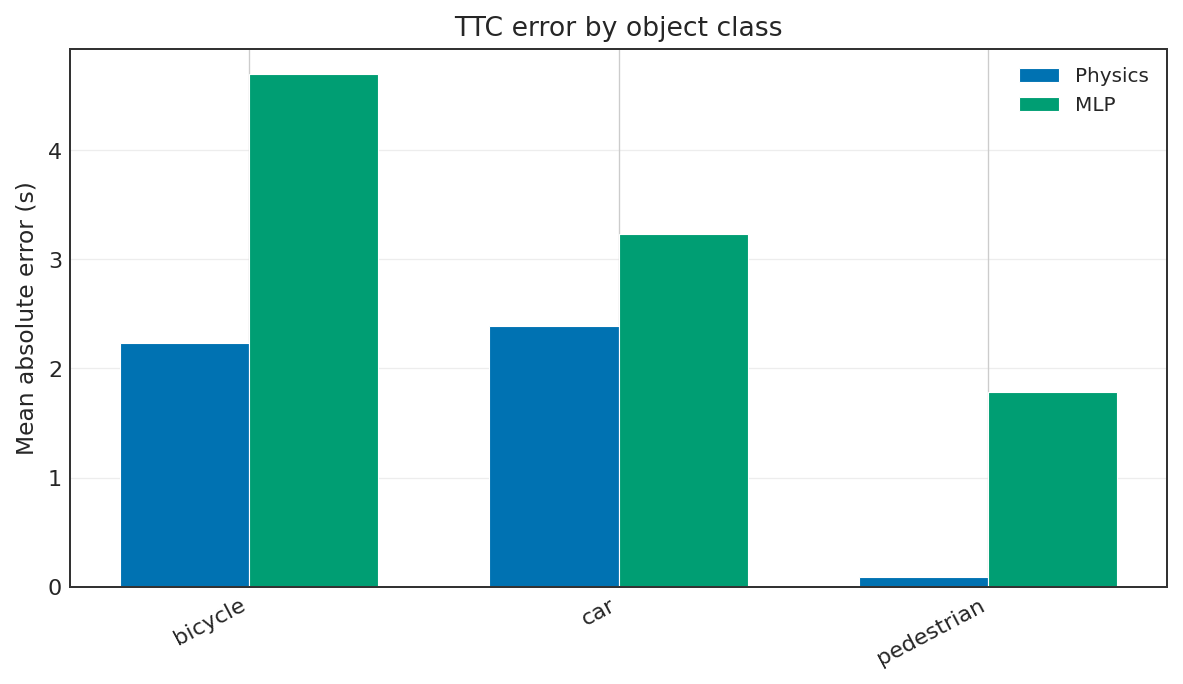

### MAE by GT TTC bin

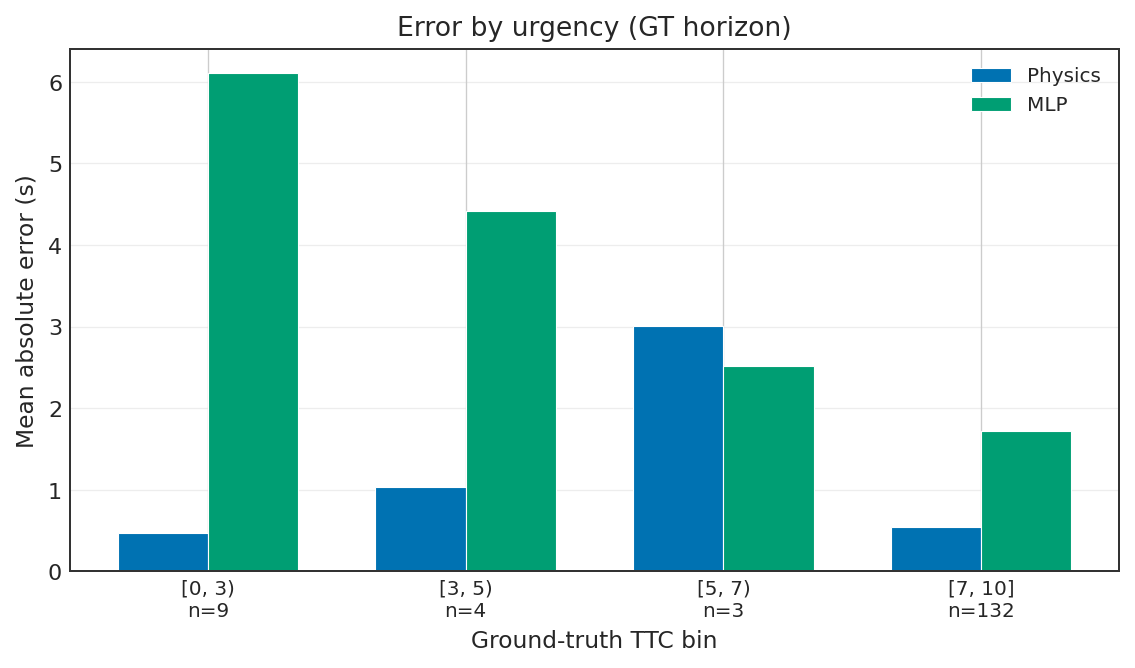

### Absolute error CDF

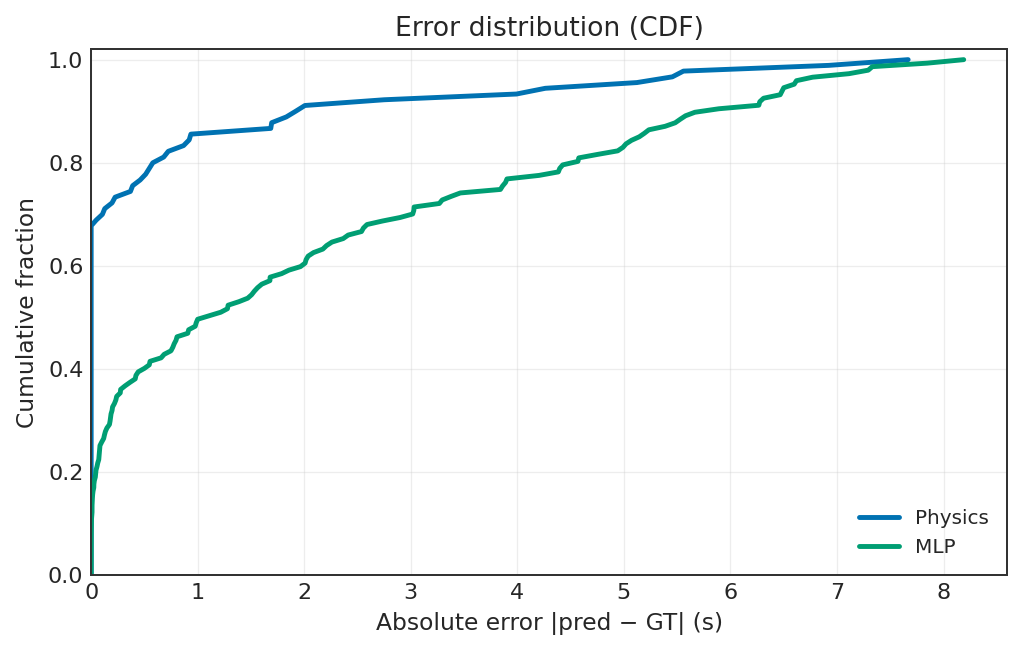

### Residual vs GT

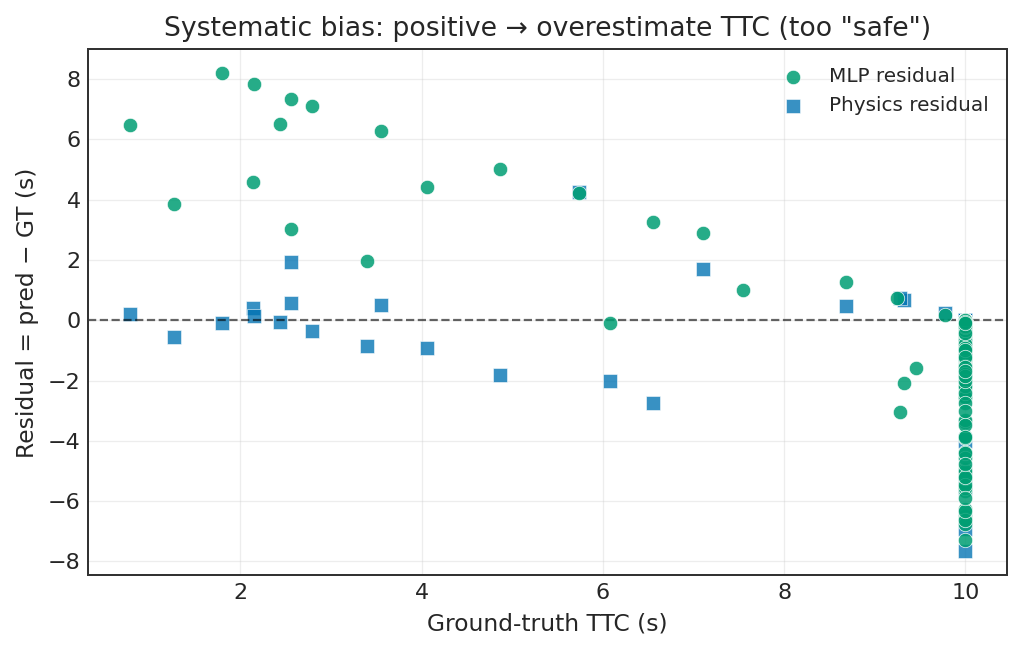

In [28]:
FIGURES = [
    ("MAE by class", "ttc_mae_by_class.png"),
    ("MAE by GT TTC bin", "ttc_mae_by_gt_bin.png"),
    ("Absolute error CDF", "ttc_error_cdf.png"),
    ("Residual vs GT", "ttc_residual_vs_gt.png"),
]

for title, name in FIGURES:
    p = SAVE_DIR / name
    display(Markdown(f"### {title}"))
    if p.is_file():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f"*({name} not found)*"))
